# Лабораторная работа №1  
## Линейная регрессия. Оценка кредитного риска

**Цель работы:** обучить линейную модель для предсказания показателя `RiskScore` по кредитным данным клиентов и добиться качества **MSE < 25**.

**Данные:**

- `train.csv` — обучающая выборка с целевой переменной `RiskScore`;
- `test.csv` — тестовая выборка без `RiskScore`;

**Основная метрика:** Mean Squared Error (MSE).  
Дополнительно считаем MAE, R², MAPE.

## 1. Импорты и вспомогательные классы

In [32]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error,
)

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    PolynomialFeatures,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, ElasticNet

# Стиль графиков и опции отображения
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

### 1.1 Собственный трансформер: обрезка по квантилям (clip)

In [33]:
class QuantileClipper(BaseEstimator, TransformerMixin):
    """
    Трансформер, который обрезает числовые признаки
    по заданным квантилям (например, 1% и 99%).
    Это уменьшает влияние сильных выбросов.
    """
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lower_bounds_ = np.nanquantile(X, self.lower, axis=0)
        self.upper_bounds_ = np.nanquantile(X, self.upper, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return np.clip(X, self.lower_bounds_, self.upper_bounds_)

## 2. Загрузка и базовый осмотр данных

In [34]:
train_path = "train.csv"
test_path = "test.csv"

# Парсим ApplicationDate сразу как дату
train = pd.read_csv(train_path, parse_dates=["ApplicationDate"])
test = pd.read_csv(test_path, parse_dates=["ApplicationDate"])

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

# Информация о типах и пропусках
train.info()

Train shape: (11017, 35)
Test shape: (5000, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11017 entries, 0 to 11016
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   ApplicationDate             10487 non-null  datetime64[ns]
 1   Age                         10487 non-null  float64       
 2   AnnualIncome                10487 non-null  float64       
 3   CreditScore                 9986 non-null   float64       
 4   LoanAmount                  9986 non-null   float64       
 5   LoanDuration                10487 non-null  float64       
 6   MaritalStatus               10487 non-null  object        
 7   NumberOfDependents          10487 non-null  float64       
 8   HomeOwnershipStatus         10487 non-null  object        
 9   MonthlyDebtPayments         9986 non-null   float64       
 10  CreditCardUtilizationRate   10487 non-null  float64       
 11  Number

## 3. Краткий EDA: распределение таргета и пропуски


### 3.1 Распределение целевой переменной RiskScore

count    1.048700e+04
mean    -2.569878e+04
std      1.431675e+06
min     -9.999999e+06
25%      3.256475e+01
50%      4.411876e+01
75%      6.535690e+01
max      1.000000e+07
Name: RiskScore, dtype: float64


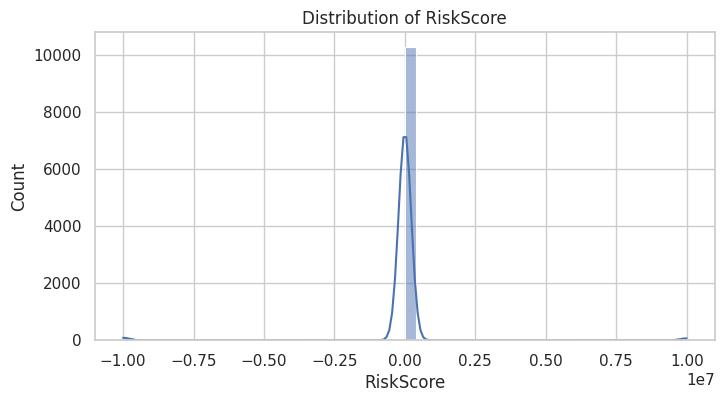

In [35]:
print(train["RiskScore"].describe())

sns.histplot(train["RiskScore"], bins=50, kde=True)
plt.title("Distribution of RiskScore")
plt.xlabel("RiskScore")
plt.show()

### 3.2 Анализ пропусков

In [36]:
missing = train.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_df = missing.to_frame("missing_count").assign(
    missing_percent=lambda df: 100 * df["missing_count"] / len(train)
)
missing_df

,missing_count,missing_percent
MonthlyDebtPayments,1031,9.358265
LoanAmount,1031,9.358265
CreditScore,1031,9.358265
BaseInterestRate,1031,9.358265
NetWorth,1031,9.358265
TotalAssets,1031,9.358265
BankruptcyHistory,1031,9.358265
LoanPurpose,1031,9.358265
CheckingAccountBalance,1031,9.358265
ApplicationDate,530,4.810747


### 3.3 Корреляции числовых признаков и тепловая карта

In [37]:
# Берём только числовые столбцы (включая RiskScore)
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()

corr_matrix = train[num_cols].corr()

# Смотрим топ-10 признаков по модулю корреляции с RiskScore
corr_with_target = corr_matrix["RiskScore"].sort_values(ascending=False)
corr_with_target.head(15)

,RiskScore
RiskScore,1.000000
PaymentHistory,0.019144
TotalDebtToIncomeRatio,0.013879
MonthlyLoanPayment,0.012366
LoanAmount,0.011771
NumberOfCreditInquiries,0.011055
NetWorth,0.008804
TotalAssets,0.008092
SavingsAccountBalance,0.007611
CreditCardUtilizationRate,0.005501


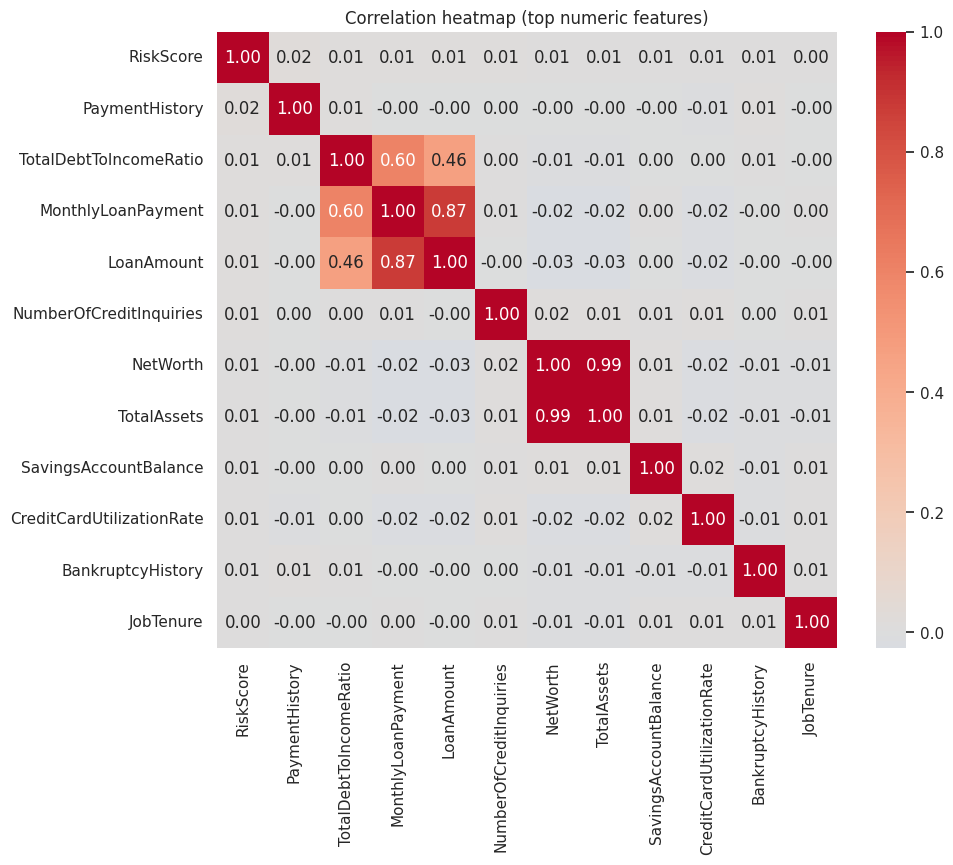

In [38]:
# Тепловая карта для подмножества признаков:
# берём таргет + несколько наиболее коррелирующих с ним
top_features = corr_with_target.index[:12]  # RiskScore + 11 самых связанных
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix.loc[top_features, top_features],
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0
)
plt.title("Correlation heatmap (top numeric features)")
plt.show()

### 3.4 Зависимость RiskScore от категориальных признаков

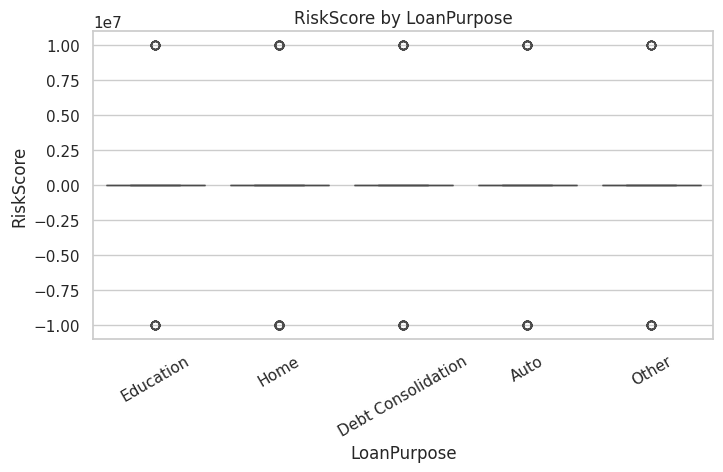

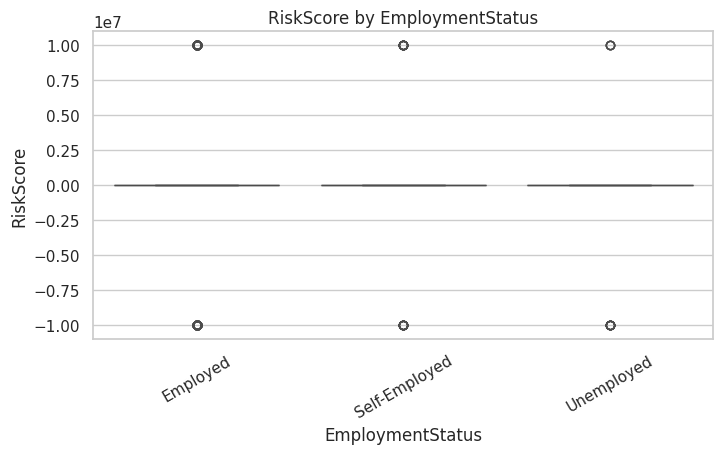

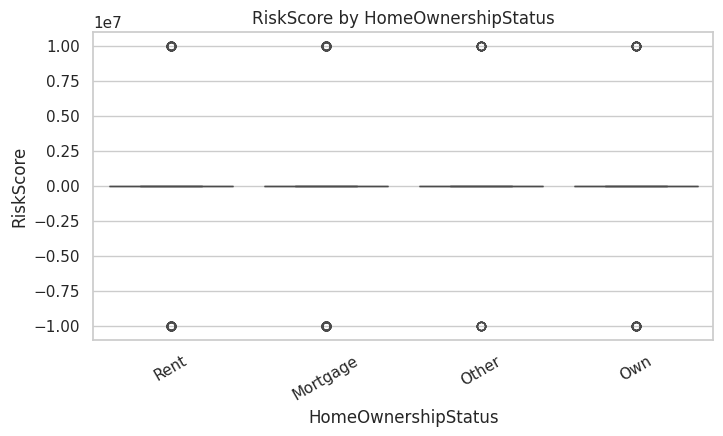

In [39]:
cat_cols_eda = ["LoanPurpose", "EmploymentStatus", "HomeOwnershipStatus"]

for col in cat_cols_eda:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=train, x=col, y="RiskScore")
    plt.title(f"RiskScore by {col}")
    plt.xticks(rotation=30)
    plt.show()

## 4. Очистка: выбросы по RiskScore и дата

### 4.1 Удаление экстремальных выбросов по RiskScore с помощью 3*IQR

In [40]:
q1 = train["RiskScore"].quantile(0.25)
q3 = train["RiskScore"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 3 * iqr
upper_bound = q3 + 3 * iqr

mask = (train["RiskScore"] >= lower_bound) & (train["RiskScore"] <= upper_bound)
train_clean = train.loc[mask].reset_index(drop=True)

print("Rows before:", len(train), "Rows after:", len(train_clean))
print("Lower bound:", lower_bound, "Upper bound:", upper_bound)


Rows before: 11017 Rows after: 10272
Lower bound: -65.81169934235419 Upper bound: 163.73334555765555


### 4.2 Разбор даты ApplicationDate на год/месяц/день недели

In [41]:
def add_date_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["ApplicationYear"] = df["ApplicationDate"].dt.year
    df["ApplicationMonth"] = df["ApplicationDate"].dt.month
    df["ApplicationDayOfWeek"] = df["ApplicationDate"].dt.dayofweek
    return df.drop(columns=["ApplicationDate"])

train_clean = add_date_features(train_clean)
test_with_date = add_date_features(test)


## 5. Инженерия признаков (FE)

### 5.1 Доменные признаки: отношения и разности

In [42]:
def add_domain_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Добавляем несколько "экономически осмысленных" признаков:
    - отношение суммы кредита к доходу,
    - отношение платежа по кредиту к доходу,
    - чистые активы,
    - спред между фактической и базовой ставками и т.д.
    """
    df = df.copy()
    eps = 1e-6

    df["loan_to_income"] = df["LoanAmount"] / (df["AnnualIncome"] + eps)
    df["payment_to_income"] = df["MonthlyLoanPayment"] / (df["MonthlyIncome"] + eps)
    df["total_debt_to_income"] = df["TotalDebtToIncomeRatio"]
    df["net_assets"] = df["TotalAssets"] - df["TotalLiabilities"]
    df["interest_spread"] = df["InterestRate"] - df["BaseInterestRate"]

    return df

train_fe = add_domain_features(train_clean)
test_fe = add_domain_features(test_with_date)


### 5.2 Логарифмирование сильно скошенных числовых признаков (log1p)

In [43]:
num_cols = train_fe.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove("RiskScore")

skew_values = train_fe[num_cols].skew()
skew_threshold = 1.0

log_candidates = [
    col for col in num_cols
    if abs(skew_values[col]) > skew_threshold and (train_fe[col] > 0).all()
]

print("Skewed numeric features for log1p:", log_candidates)

for col in log_candidates:
    new_col = f"{col}_log1p"
    train_fe[new_col] = np.log1p(train_fe[col])
    test_fe[new_col] = np.log1p(test_fe[col])


Skewed numeric features for log1p: ['SavingsAccountBalance', 'TotalLiabilities', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'payment_to_income', 'total_debt_to_income']


### 5.3 Target encoding для категориальных признаков

In [44]:
cat_cols = [
    "MaritalStatus",
    "HomeOwnershipStatus",
    "LoanPurpose",
    "EmploymentStatus",
    "EducationLevel",
]

def add_target_encoding(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    cat_columns,
    target_col="RiskScore",
    global_smoothing=5.0,
):
    """
    Для каждой категории считаем сглаженную среднюю RiskScore
    и записываем её в новый числовой признак <col>_te.
    """
    train_df = train_df.copy()
    test_df = test_df.copy()

    global_mean = train_df[target_col].mean()
    te_cols = []

    for col in cat_columns:
        stats = train_df.groupby(col)[target_col].agg(["mean", "count"])
        smooth = (stats["mean"] * stats["count"] +
                  global_mean * global_smoothing) / (stats["count"] + global_smoothing)
        mapping = smooth.to_dict()

        te_col = f"{col}_te"
        te_cols.append(te_col)

        train_df[te_col] = train_df[col].map(mapping).fillna(global_mean)
        test_df[te_col] = test_df[col].map(mapping).fillna(global_mean)

    return train_df, test_df, te_cols

train_fe_te, test_fe_te, te_cols = add_target_encoding(
    train_fe, test_fe, cat_cols, target_col="RiskScore", global_smoothing=5.0
)

print("Target encoding columns:", te_cols)


Target encoding columns: ['MaritalStatus_te', 'HomeOwnershipStatus_te', 'LoanPurpose_te', 'EmploymentStatus_te', 'EducationLevel_te']


### 5.4 Квантильные бины для наиболее важных числовых признаков

In [45]:
numeric_features_te = [
    c for c in train_fe_te.select_dtypes(include=[np.number]).columns
    if c != "RiskScore"
]

# "Базовые" числовые для оценки корреляции (без TE и логов)
base_num_cols = [
    c for c in numeric_features_te
    if not c.endswith("_te") and not c.endswith("_log1p")
]

y_arr = train_fe_te["RiskScore"].values
numeric_corr = {}

for col in base_num_cols:
    s = train_fe_te[col].values
    mask = np.isfinite(s) & np.isfinite(y_arr)
    if mask.sum() < 50:
        continue
    c = np.corrcoef(s[mask], y_arr[mask])[0, 1]
    if np.isfinite(c):
        numeric_corr[col] = abs(c)

numeric_corr_sorted = sorted(numeric_corr.items(), key=lambda x: x[1], reverse=True)
top_bin_cols = [c for c, _ in numeric_corr_sorted[:5]]

print("Top numeric features for binning:", top_bin_cols)

for col in top_bin_cols:
    s = train_fe_te[col]
    mask = np.isfinite(s.values)
    valid = s.values[mask]
    if valid.size < 50:
        continue
    _, bin_edges = pd.qcut(valid, q=10, retbins=True, duplicates="drop")
    bin_col = f"{col}_bin"
    train_fe_te[bin_col] = pd.cut(train_fe_te[col], bins=bin_edges, include_lowest=True)
    test_fe_te[bin_col] = pd.cut(test_fe_te[col], bins=bin_edges, include_lowest=True)


Top numeric features for binning: ['CreditScore', 'MonthlyIncome', 'BaseInterestRate', 'AnnualIncome', 'InterestRate']


### 5.5 Финальный список числовых и категориальных признаков

In [46]:
categorical_features = cat_cols + [f"{c}_bin" for c in top_bin_cols]

numeric_features = [
    c for c in train_fe_te.select_dtypes(include=[np.number]).columns
    if c != "RiskScore"
]

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))


Numeric features: 47
Categorical features: 10


## 6. Разбиение train/valid и базовый LinearRegression

### 6.1 Разделение на обучающую и валидационную выборки

In [47]:
X = train_fe_te.drop(columns=["RiskScore"])
y = train_fe_te["RiskScore"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)


### 6.2 Базовая линейная регрессия (без poly2, для сравнения)

In [48]:
numeric_simple = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_simple = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor_simple = ColumnTransformer(
    transformers=[
        ("num", numeric_simple, numeric_features),
        ("cat", categorical_simple, categorical_features),
    ]
)

baseline_lr = Pipeline(steps=[
    ("preprocessor", preprocessor_simple),
    ("model", LinearRegression()),
])

baseline_lr.fit(X_train, y_train)
y_valid_pred_lr = baseline_lr.predict(X_valid)

mse_lr = mean_squared_error(y_valid, y_valid_pred_lr)
mae_lr = mean_absolute_error(y_valid, y_valid_pred_lr)
r2_lr = r2_score(y_valid, y_valid_pred_lr)
mape_lr = mean_absolute_percentage_error(y_valid, y_valid_pred_lr) * 100

print(f"LinearRegression MSE:  {mse_lr:.4f}")
print(f"LinearRegression MAE:  {mae_lr:.4f}")
print(f"LinearRegression R^2:  {r2_lr:.4f}")
print(f"LinearRegression MAPE: {mape_lr:.2f}%")


LinearRegression MSE:  36.5546
LinearRegression MAE:  4.5340
LinearRegression R^2:  0.8778
LinearRegression MAPE: 10.65%


## 7. Финальный пайплайн: ElasticNet + poly2 + clip

### 7.1 Финальный препроцессор: poly2 + clip + масштабирование

In [49]:
numeric_transformer_final = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clipper", QuantileClipper(lower=0.01, upper=0.99)),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
])

categorical_transformer_final = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01)),
])

preprocessor_final = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_final, numeric_features),
        ("cat", categorical_transformer_final, categorical_features),
    ]
)


### 7.2 Модель ElasticNet и подбор гиперпараметров по 5-fold CV

In [51]:
elastic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_final),
    ("model", ElasticNet(max_iter=20000, random_state=42)),
])

alpha_grid = [0.01, 0.02, 0.03]
l1_ratio_grid = [0.96, 0.98, 0.995]

param_grid = {
    "model__alpha": alpha_grid,
    "model__l1_ratio": l1_ratio_grid,
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

elastic_gs = GridSearchCV(
    estimator=elastic_pipeline,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

elastic_gs.fit(X, y)

print("Best params (final ElasticNet):", elastic_gs.best_params_)
print("Best CV MSE (final):", -elastic_gs.best_score_)


Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best params (final ElasticNet): {'model__alpha': 0.03, 'model__l1_ratio': 0.98}
Best CV MSE (final): 26.074564711819164


### 7.3 Оценка лучшей модели на валидационном сплите

In [52]:
best_final = elastic_gs.best_estimator_

y_valid_pred_final = best_final.predict(X_valid)

mse_final = mean_squared_error(y_valid, y_valid_pred_final)
mae_final = mean_absolute_error(y_valid, y_valid_pred_final)
r2_final = r2_score(y_valid, y_valid_pred_final)
mape_final = mean_absolute_percentage_error(y_valid, y_valid_pred_final) * 100

print(f"Final ElasticNet MSE:   {mse_final:.4f}")
print(f"Final ElasticNet MAE:   {mae_final:.4f}")
print(f"Final ElasticNet R^2:   {r2_final:.4f}")
print(f"Final ElasticNet MAPE:  {mape_final:.2f}%")


Final ElasticNet MSE:   24.4035
Final ElasticNet MAE:   3.6481
Final ElasticNet R^2:   0.9184
Final ElasticNet MAPE:  8.53%


## 8. Обучение на всём train и Kaggle submission

In [53]:
# Обучаем лучшую модель на всей train-features
best_final.fit(X, y)

# Формируем матрицу признаков для теста
X_test_all = test_fe_te[numeric_features + categorical_features]

# Предсказываем RiskScore для тестовой выборки
y_test_pred = best_final.predict(X_test_all)

# Готовим файл для Kaggle
submission = pd.DataFrame({
    "ID": test["ID"],
    "RiskScore": y_test_pred
})

submission.head()
submission.to_csv("submission_final.csv", index=False)
print("Saved submission_final.csv")


Saved submission_final.csv
